In [1]:
import numpy as np
import pandas as pd
import scipy.interpolate
import scipy.optimize
import scipy.signal
from parse_rating import parse_rating
import matplotlib.pyplot as plt

In [2]:
cfs_to_cms = 0.0283168
ft_to_m = 0.3048

In [3]:
hand_table = pd.read_csv('hydroTable.csv')

In [4]:
gageid_to_hydroid = pd.read_excel('USGSHoustonGauges_Project_TableToExcel.xlsx')
gageid_to_hydroid['stationid'] = gageid_to_hydroid['stationid'].str[2:]
gageid_to_hydroid = gageid_to_hydroid[['stationid', 'HydroID']].set_index('stationid')['HydroID']

In [5]:
usgs_ratings = {}
for station_id in gageid_to_hydroid.index:
    filename = f'./usgs_ratings/USGS.{station_id}.base.rdb'
    if os.path.exists(filename):
        usgs_rating = parse_rating(filename)
        usgs_rating['INDEP'] -= usgs_rating['INDEP'].min()
        usgs_rating['INDEP'] *= ft_to_m
        usgs_rating['DEP'] *= cfs_to_cms
        usgs_ratings[station_id] = usgs_rating

In [6]:
hand_ratings = {}
for station_id in gageid_to_hydroid.index:
    hydroid = gageid_to_hydroid[station_id]
    reach_table = hand_table[hand_table['HydroID'] == hydroid]
    hand_rating = reach_table[['stage', 'discharge_cms', 'HydraulicRadius (m)', 'WetArea (m2)', 'SLOPE', 'ManningN']]
    hand_ratings[station_id] = hand_rating

In [7]:
usgs = usgs_ratings['08073600']

In [8]:
hand = hand_ratings['08073600'].reset_index(drop=True)
hand.columns = ['h', 'Q', 'R', 'A', 'S_0', 'n']
hand['P'] = (hand['A'] / hand['R']).fillna(0.)

In [9]:
h = hand['h'].values.copy()
A = hand['A'].values.copy()
P = hand['P'].values.copy()

In [10]:
A = np.maximum.accumulate(A)
P = np.maximum.accumulate(P)
for i in range(len(P)):
    if (P[i] == P[i-1]):
        P[i:] += 1e-3
dP = np.diff(P)

In [11]:
B = (A[1:] - A[:-1]) / (h[1:] - h[:-1])
B = np.maximum.accumulate(B)
dB = np.diff(np.asarray([0.] + B.tolist()))

In [12]:
A_segs = []
R_segs = []

hsats = []
for i in range(len(dB)):
    hsat = np.maximum(h - h[i], 0.)
    A_seg = dB[i] * hsat
    P_seg = dP[i]
    R_seg = np.maximum(A_seg / P_seg, 0.)
    A_segs.append(A_seg)
    R_segs.append(R_seg)

A_segs = np.vstack(A_segs)
R_segs = np.vstack(R_segs)

In [13]:
u_segs = []
Q_segs = []

for A_seg, R_seg in zip(A_segs, R_segs):
    u = (1 / 0.125) * R_seg**(2/3) * np.sqrt(0.001)
    Q = u * A_seg
    u_segs.append(u)
    Q_segs.append(Q)

u_segs = np.vstack(u_segs)
Q_segs = np.vstack(Q_segs)

Text(0.5, 1.0, 'Stacked discharges by segment')

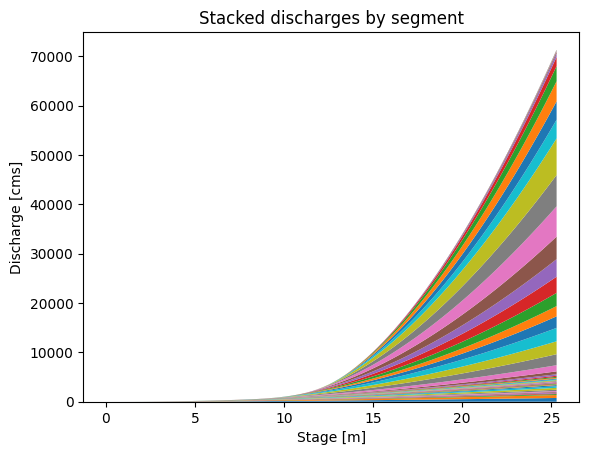

In [14]:
_ = plt.stackplot(h, *Q_segs)
plt.ylabel('Discharge [cms]')
plt.xlabel('Stage [m]')
plt.title('Stacked discharges by segment')

In [15]:
interp = scipy.interpolate.CubicSpline(usgs['INDEP'].values, usgs['DEP'].values)
cond = h <= usgs['INDEP'].max()
Q_ref = interp(h[cond])

In [16]:
def opt_fun(x, A_segs, R_segs, Q_ref, cond):
    n = x[:-1]
    S_0 = x[-1]
    Q_segs = []
    for i in range(len(n)):
        ni = n[i]
        R_seg = R_segs[i]
        A_seg = A_segs[i]
        u = (1 / n[i]) * R_seg**(2/3) * np.sqrt(S_0)
        Q = u * A_seg
        Q = Q[cond]
        Q_segs.append(Q)
    Q_segs = np.vstack(Q_segs)
    Q_comp = Q_segs.sum(axis=0)
    return ((Q_comp - Q_ref)**2).mean()

In [17]:
x0 = np.zeros(cond.size)
x0[:-1] = 0.125 * np.ones(cond.size - 1)
x0[-1] = 0.001
opt_result = scipy.optimize.minimize(opt_fun, x0, args=(A_segs, R_segs, Q_ref, cond), bounds=[(1e-5, 0.1) for _ in range(x0.size - 1)] + [(1e-6, 0.01)])

In [18]:
opt_result

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 135.9207346085047
        x: [ 4.453e-03  9.322e-02 ...  1.000e-01  3.595e-06]
      nit: 83
      jac: [-3.031e+04 -6.220e+01 ... -0.000e+00  2.985e+07]
     nfev: 13600
     njev: 160
 hess_inv: <84x84 LbfgsInvHessProduct with dtype=float64>

In [19]:
n_opt = opt_result.x[:-1]
S_0_opt = opt_result.x[-1]

In [20]:
u_segs = []
Q_segs = []

for i in range(len(A_segs)):
    u = (1 / n_opt[i]) * R_segs[i]**(2/3) * np.sqrt(S_0_opt)
    Q = u * A_segs[i]
    u_segs.append(u)
    Q_segs.append(Q)

u_segs = np.vstack(u_segs)
Q_segs = np.vstack(Q_segs)

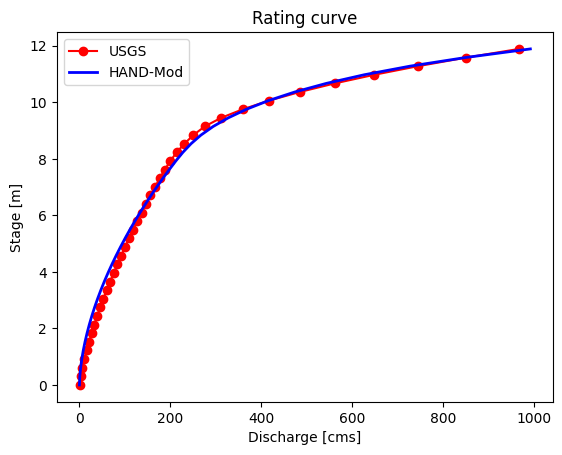

In [21]:
plt.plot(Q_ref, h[cond], marker='o', c='r', label='USGS')
plt.plot(Q_segs.sum(axis=0)[cond], h[cond], c='b', label='HAND-Mod', linewidth=2)
plt.xlabel('Discharge [cms]')
plt.ylabel('Stage [m]')
plt.title('Rating curve')
plt.legend()

In [22]:
print('Optimized slope:', S_0_opt)

Optimized slope: 3.5949044300585925e-06


Text(0, 0.5, 'n [-]')

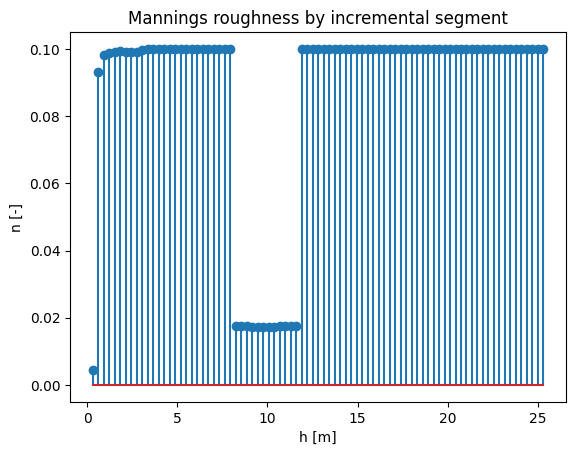

In [23]:
plt.stem(h[1:], n_opt)
plt.title('Mannings roughness by incremental segment')
plt.xlabel('h [m]')
plt.ylabel('n [-]')